# 0.8.1 — Deep Dive: Top 15% of Customers by Spend

Who are the highest-value customers, and are they actually different from everyone else? Part of [`0.8_consumer_base_analysis.ipynb`](0.8_consumer_base_analysis.ipynb) — see that notebook for why the analysis window is restricted to **Jan 2015 – Sep 2017** (the Nov 2017+ data break mints one-order-only customer IDs that would distort any ranking by spend) and why spend is measured as `Order Item Total` (net of discount).

"Top 15%" here means the top 15% of customers ranked by **total net spend** over the window — 1,850 of 12,330 customers.

## Load & prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def dollars(v, _):
    return f'${v:,.0f}'

DATA_DIR = '.'

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['month'] = df['order date (DateOrders)'].dt.to_period('M')
clean = df[df['order date (DateOrders)'] < '2017-10-01'].copy()

order_level = clean.drop_duplicates('Order Id').set_index('Order Id')
profit_by_cust = order_level.groupby('Order Customer Id')['Order Profit Per Order'].sum()

cust = clean.groupby('Order Customer Id').agg(
    n_orders=('Order Id', 'nunique'),
    total_spend=('Order Item Total', 'sum'),
    avg_discount_rate=('Order Item Discount Rate', 'mean'),
    late_risk_rate=('Late_delivery_risk', 'mean'),
    segment=('Customer Segment', lambda s: s.mode()[0]),
    market=('Market', lambda s: s.mode()[0]),
    region=('Order Region', lambda s: s.mode()[0]),
    first_order=('order date (DateOrders)', 'min'),
    last_order=('order date (DateOrders)', 'max'),
).reset_index()
cust['total_profit'] = cust['Order Customer Id'].map(profit_by_cust)
cust['aov'] = cust['total_spend'] / cust['n_orders']
cust['tenure_days'] = (cust['last_order'] - cust['first_order']).dt.days
END = clean['order date (DateOrders)'].max()
cust['recency_days'] = (END - cust['last_order']).dt.days

cust = cust.sort_values('total_spend', ascending=False).reset_index(drop=True)
N15 = int(np.ceil(len(cust) * 0.15))
cust['grp'] = ['Top 15%'] * N15 + ['Rest 85%'] * (len(cust) - N15)
top15_ids = set(cust.loc[cust['grp'] == 'Top 15%', 'Order Customer Id'])
clean['grp'] = np.where(clean['Order Customer Id'].isin(top15_ids), 'Top 15%', 'Rest 85%')

threshold = cust.loc[cust['grp'] == 'Top 15%', 'total_spend'].min()
print(f"{N15:,} customers qualify (spend >= ${threshold:,.0f} over the window)")

1,850 customers qualify (spend >= $3,865 over the window)


## Scorecard

In [3]:
top15 = cust[cust['grp'] == 'Top 15%']
rest = cust[cust['grp'] == 'Rest 85%']

rev_share = top15['total_spend'].sum() / cust['total_spend'].sum() * 100
profit_share = top15['total_profit'].sum() / cust['total_profit'].sum() * 100
margin_top15 = top15['total_profit'].sum() / top15['total_spend'].sum() * 100
margin_rest = rest['total_profit'].sum() / rest['total_spend'].sum() * 100

print(f"customers:        15.0% of the base")
print(f"revenue share:     {rev_share:.1f}%")
print(f"profit share:      {profit_share:.1f}%")
print(f"profit margin:     {margin_top15:.2f}% (top 15%)  vs  {margin_rest:.2f}% (rest 85%)")

customers:        15.0% of the base
revenue share:     28.7%
profit share:      26.2%
profit margin:     3.31% (top 15%)  vs  3.74% (rest 85%)


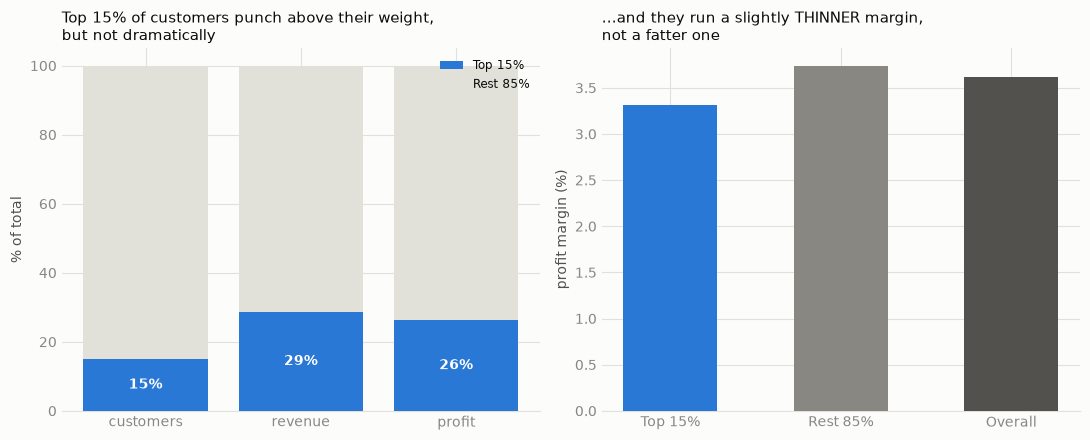

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
cats = ['customers', 'revenue', 'profit']
top_vals = [15.0, rev_share, profit_share]
rest_vals = [85.0, 100 - rev_share, 100 - profit_share]
ax.bar(cats, top_vals, color=BLUE, label='Top 15%', zorder=3)
ax.bar(cats, rest_vals, bottom=top_vals, color=GRID, label='Rest 85%', zorder=3)
for i, v in enumerate(top_vals):
    ax.text(i, v / 2, f'{v:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
ax.set_ylabel('% of total')
ax.set_title('Top 15% of customers punch above their weight,\nbut not dramatically', loc='left', color=INK, fontsize=10.5)
ax.legend(frameon=False, loc='upper right', fontsize=8.5)
style_axis(ax)

ax = axes[1]
ax.bar(['Top 15%', 'Rest 85%', 'Overall'], [margin_top15, margin_rest, cust['total_profit'].sum() / cust['total_spend'].sum() * 100],
       color=[BLUE, INK_MUTED, INK_SECONDARY], width=0.55, zorder=3)
ax.set_ylabel('profit margin (%)')
ax.set_title('...and they run a slightly THINNER margin,\nnot a fatter one', loc='left', color=INK, fontsize=10.5)
style_axis(ax)

plt.tight_layout()
plt.show()

Your highest-revenue customers are not your highest-margin ones: they generate 28.7% of revenue and 26.2% of profit off 15% of the customer base — solid over-indexing — but their profit margin (3.31%) is meaningfully *below* the rest of the base (3.74%). Ranking by spend and ranking by profitability would surface two different (if overlapping) lists.

## They're not a different kind of customer — they're a more active one

In [5]:
compare = cust.groupby('grp').agg(
    n_orders=('n_orders', 'mean'),
    aov=('aov', 'mean'),
    tenure_days=('tenure_days', 'mean'),
    recency_days=('recency_days', 'mean'),
).round(1)
compare

,n_orders,aov,tenure_days,recency_days
grp,,,,
Rest 85%,4.1,519.9,557.7,222.0
Top 15%,7.7,631.7,765.6,120.0


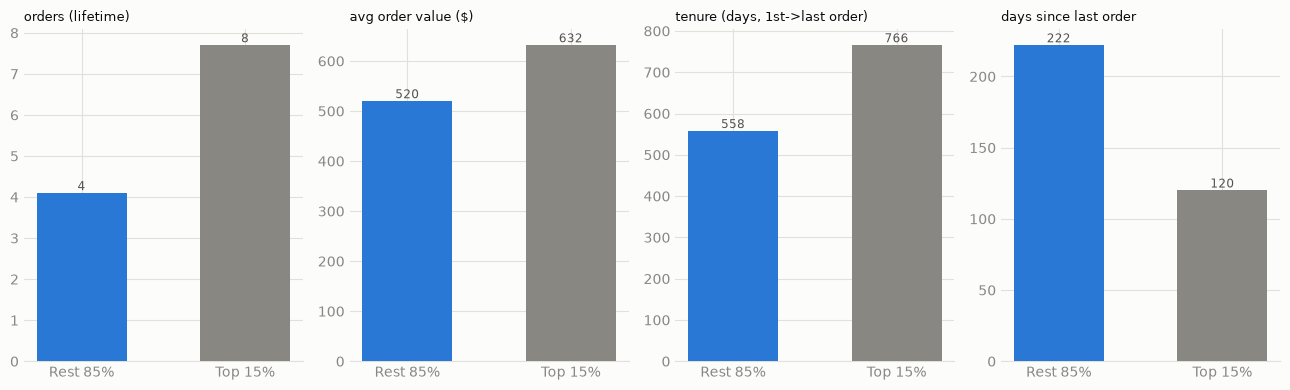

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
metrics = [('n_orders', 'orders (lifetime)', axes[0]), ('aov', 'avg order value ($)', axes[1]),
           ('tenure_days', 'tenure (days, 1st->last order)', axes[2]), ('recency_days', 'days since last order', axes[3])]
for col, label, ax in metrics:
    vals = compare[col]
    colors = [BLUE, INK_MUTED]
    ax.bar(vals.index, vals.values, color=colors, width=0.55, zorder=3)
    ax.set_title(label, loc='left', color=INK, fontsize=9.5)
    style_axis(ax)
    for i, v in enumerate(vals.values):
        ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8.5, color=INK_SECONDARY)
plt.tight_layout()
plt.show()

Top-15% customers order almost **twice as often** (7.7 vs 4.1 lifetime orders), have been customers **longer** (766 vs 558 days tenure), and are **more recently active** (last order 120 days ago vs 222) than everyone else. They spend somewhat more per order too (§4 of `0.8` already showed frequency and order size aren't correlated in general — but ranking by *total* spend naturally selects people who are elevated on both). This is an engaged, growing-tenure group, not a shrinking cohort of legacy big spenders — good news if the goal is retaining them.

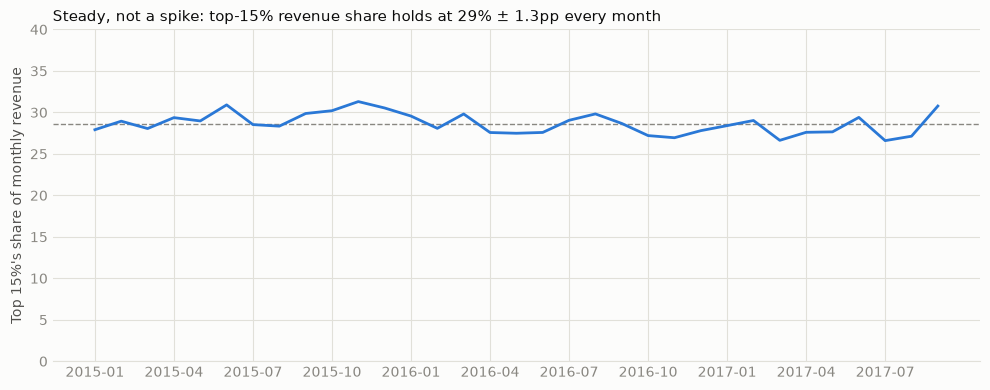

In [7]:
monthly_share = clean.groupby(['month', 'grp'])['Order Item Total'].sum().unstack()
monthly_share_pct = monthly_share.div(monthly_share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_share_pct.index.astype(str), monthly_share_pct['Top 15%'], color=BLUE, linewidth=2, zorder=3)
ax.axhline(monthly_share_pct['Top 15%'].mean(), color=INK_MUTED, linestyle='--', linewidth=1, zorder=2)
ax.set_ylim(0, 40)
ax.set_ylabel("Top 15%'s share of monthly revenue")
ax.set_title(f"Steady, not a spike: top-15% revenue share holds at {monthly_share_pct['Top 15%'].mean():.0f}% ± {monthly_share_pct['Top 15%'].std():.1f}pp every month", loc='left', color=INK, fontsize=10.5)
ax.set_xticks(ax.get_xticks()[::3])
style_axis(ax)
plt.tight_layout()
plt.show()

## Where they are, what they buy, how they're served

In [8]:
mkt_mix = pd.crosstab(cust['grp'], cust['market'], normalize='index').T * 100
mkt_mix['index_ratio'] = mkt_mix['Top 15%'] / mkt_mix['Rest 85%']
mkt_mix.round(2).sort_values('index_ratio', ascending=False)

grp,Rest 85%,Top 15%,index_ratio
market,,,
Europe,31.89,34.49,1.08
LATAM,33.06,35.84,1.08
Pacific Asia,17.52,17.57,1.00
USCA,11.32,9.24,0.82
Africa,6.21,2.86,0.46


In [9]:
region_mix = pd.crosstab(cust['grp'], cust['region'], normalize='index').T * 100
region_mix['index_ratio'] = region_mix['Top 15%'] / region_mix['Rest 85%']
region_mix.sort_values('Rest 85%', ascending=False).round(2).head(10)

grp,Rest 85%,Top 15%,index_ratio
region,,,
Central America,22.93,28.86,1.26
Western Europe,14.06,18.92,1.35
South America,8.66,9.19,1.06
Caribbean,5.51,6.22,1.13
Northern Europe,5.12,5.24,1.02
Oceania,4.56,3.78,0.83
East of USA,4.33,3.51,0.81
Southern Europe,4.30,3.73,0.87
West of USA,3.72,2.70,0.73


A mild geographic lean — Central America and Western Europe are slightly over-represented among top spenders (29% vs 23%, and 19% vs 14% of each group respectively) — but nothing close to concentration in one region. `Market` and `Customer Segment` (checked in `0.8` §7) both track the overall base closely.

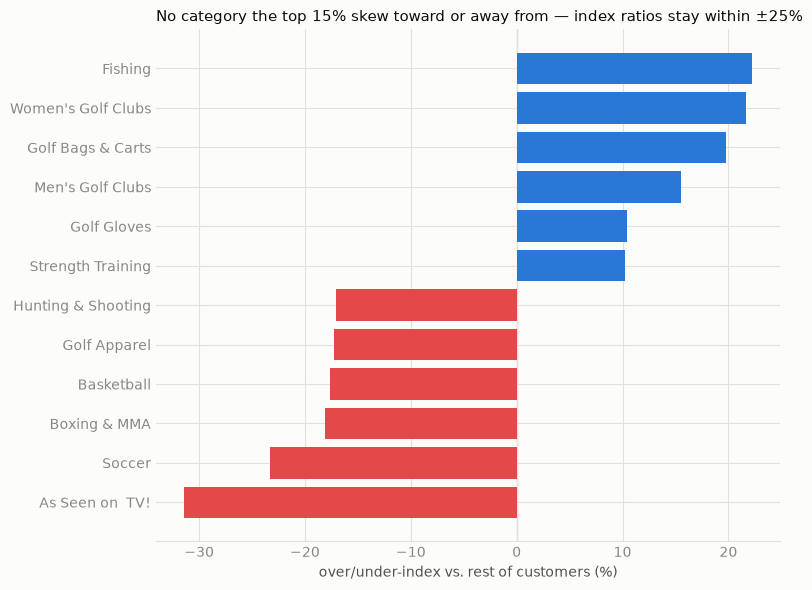

index ratio range across all 32 categories: 0.69x - 1.22x


In [10]:
cat_top = clean.loc[clean['grp'] == 'Top 15%', 'Category Name'].value_counts(normalize=True) * 100
cat_rest = clean.loc[clean['grp'] == 'Rest 85%', 'Category Name'].value_counts(normalize=True) * 100
cat_idx = (cat_top / cat_rest).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
show = pd.concat([cat_idx.head(6), cat_idx.tail(6)])
colors = [BLUE if v >= 1 else NEG for v in show.values]
ax.barh(show.index[::-1], (show.values - 1)[::-1] * 100, color=colors[::-1], zorder=3)
ax.axvline(0, color=GRID, linewidth=1)
ax.set_xlabel('over/under-index vs. rest of customers (%)')
ax.set_title('No category the top 15% skew toward or away from — index ratios stay within ±25%', loc='left', color=INK, fontsize=10.5)
style_axis(ax, x_grid=True)
plt.tight_layout()
plt.show()

print(f"index ratio range across all {cat_idx.shape[0]} categories: {cat_idx.min():.2f}x - {cat_idx.max():.2f}x")

In [11]:
for col in ['Shipping Mode', 'Type', 'Delivery Status']:
    print(f"=== {col} ===")
    print((pd.crosstab(clean['grp'], clean[col], normalize='index') * 100).round(1))
    print()

print(f"avg discount rate: top15 {top15['avg_discount_rate'].mean()*100:.1f}%  vs  rest {rest['avg_discount_rate'].mean()*100:.1f}%")
print(f"late delivery risk: top15 {top15['late_risk_rate'].mean()*100:.1f}%  vs  rest {rest['late_risk_rate'].mean()*100:.1f}%")

=== Shipping Mode ===
Shipping Mode  First Class  Same Day  Second Class  Standard Class
grp                                                               
Rest 85%              15.3       5.4          19.4            59.9
Top 15%               15.7       5.5          19.7            59.2

=== Type ===
Type      CASH  DEBIT  PAYMENT  TRANSFER
grp                                     
Rest 85%  11.0   38.5     23.1      27.4
Top 15%   10.4   38.1     23.3      28.2

=== Delivery Status ===
Delivery Status  Advance shipping  Late delivery  Shipping canceled  Shipping on time
grp                                                                                  
Rest 85%                     23.3           54.7                4.2              17.8
Top 15%                      22.5           55.2                4.4              17.9

avg discount rate: top15 10.0%  vs  rest 10.2%
late delivery risk: top15 55.1%  vs  rest 54.5%


Product mix, shipping mode, payment type, delivery reliability, and discount rate are all essentially identical between the top 15% and everyone else. There's no operational signal here — they aren't being routed through a different fulfillment path, offered different discounts, or shopping a different catalog. The only thing that distinguishes them is **how much and how often they buy**, not who they are or what they buy.

## 4. Early predictors — can we flag a future top-15% customer from their first 90 days?

Everything above is retrospective — it describes who top-15% customers turn out to be, using their *entire* spend history. That's not actionable at the point you'd actually want to act: right after someone's first order. This section asks whether first-order and first-90-day behavior — order size, category, and how fast they come back — carries enough signal to flag them early.

To keep the 90-day window uncensored (not cut off by the Oct 2017 artifact boundary), this restricts to customers whose first order was on or before `2017-10-01 minus 90 days`. That excludes only 62 of 12,330 customers (0.5%) — negligible cohort bias, unlike the eligibility filters elsewhere in this archive that meaningfully shrink the population.

In [12]:
WINDOW = 90
RUNWAY_CUTOFF = pd.Timestamp('2017-10-01') - pd.Timedelta(days=WINDOW)

order_totals = clean.groupby('Order Id').agg(
    customer=('Order Customer Id', 'first'),
    order_date=('order date (DateOrders)', 'first'),
    order_value=('Order Item Total', 'sum'),
    top_category=('Category Name', lambda s: s.mode()[0]),
).reset_index()
order_totals = order_totals.sort_values(['customer', 'order_date'])
order_totals['seq'] = order_totals.groupby('customer').cumcount() + 1

first_orders = order_totals[order_totals['seq'] == 1].set_index('customer')
second_orders = order_totals[order_totals['seq'] == 2].set_index('customer')

early = cust.set_index('Order Customer Id')[['grp']].copy()
early['is_top15'] = early['grp'] == 'Top 15%'
early['first_order_date'] = first_orders['order_date']
early['first_order_value'] = first_orders['order_value']
early['first_order_category'] = first_orders['top_category']
early['days_to_2nd_order'] = (second_orders['order_date'] - first_orders['order_date']).dt.days
eligible = early['first_order_date'] <= RUNWAY_CUTOFF

merged = order_totals.merge(early[['first_order_date']], left_on='customer', right_index=True)
merged['days_since_first'] = (merged['order_date'] - merged['first_order_date']).dt.days
w = merged[(merged['days_since_first'] >= 0) & (merged['days_since_first'] <= WINDOW)]
agg90 = w.groupby('customer').agg(n_orders_90d=('Order Id', 'nunique'), spend_90d=('order_value', 'sum'))
early = early.join(agg90)
early['reordered_within_90d'] = (early['days_to_2nd_order'] <= WINDOW).fillna(False)

early = early[eligible].copy()
print(f"{len(early):,} customers with a full 90-day runway before the data break "
      f"({eligible.sum() / len(eligible) * 100:.1f}% of the base) -- top-15% rate {early['is_top15'].mean()*100:.1f}%, matches overall")

12,268 customers with a full 90-day runway before the data break (99.5% of the base) -- top-15% rate 15.1%, matches overall


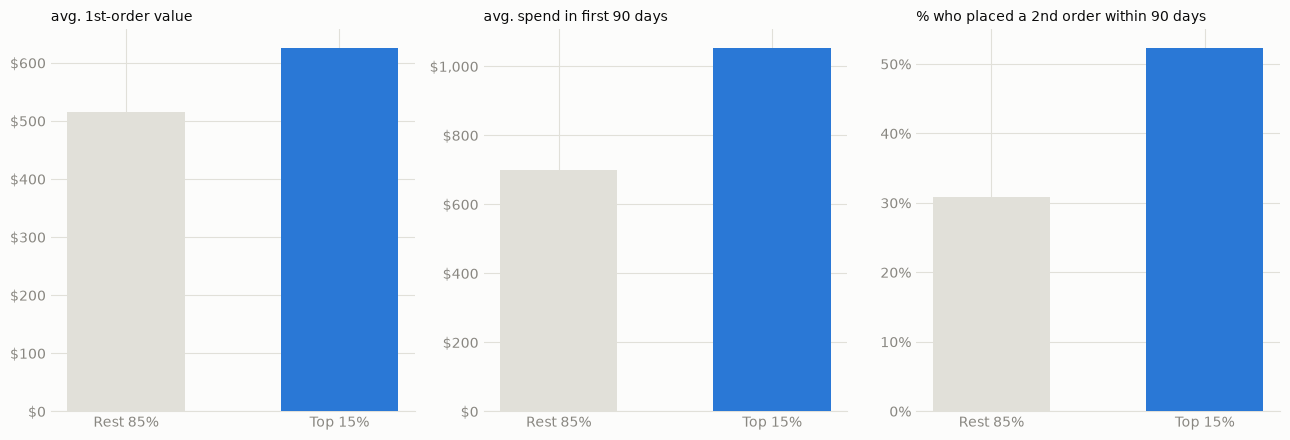

          first_order_value  spend_90d  n_orders_90d  reorder_rate_90d
is_top15                                                              
False               514.740    700.291         1.368             0.309
True                626.191   1054.188         1.694             0.524
corr(first_order_value, is_top15) = +0.132
corr(spend_90d, is_top15) = +0.256
corr(n_orders_90d, is_top15) = +0.180
corr(reordered_within_90d, is_top15) = +0.162


In [13]:
grp_means = early.groupby('is_top15').agg(
    first_order_value=('first_order_value', 'mean'),
    spend_90d=('spend_90d', 'mean'),
    n_orders_90d=('n_orders_90d', 'mean'),
    reorder_rate_90d=('reordered_within_90d', 'mean'),
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
panels = [
    ('first_order_value', 'avg. 1st-order value'),
    ('spend_90d', 'avg. spend in first 90 days'),
    ('reorder_rate_90d', '% who placed a 2nd order within 90 days'),
]
for ax, (col, title) in zip(axes, panels):
    vals = grp_means[col]
    colors = [GRID, BLUE]
    bars = ax.bar(['Rest 85%', 'Top 15%'], vals.reindex([False, True]), color=colors, width=0.55, zorder=3)
    if col == 'reorder_rate_90d':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollars))
    ax.set_title(title, loc='left', color=INK, fontsize=10)
    style_axis(ax, x_grid=False)
plt.tight_layout()
plt.show()

print(grp_means.round(3))
y = early['is_top15'].astype(int)
for col in ['first_order_value', 'spend_90d', 'n_orders_90d', 'reordered_within_90d']:
    print(f"corr({col}, is_top15) = {y.corr(early[col].astype(float)):+.3f}")

First-order size alone is a weak signal (\$626 vs \$515, corr +0.13) — a customer's very first basket barely moves the needle. **90-day spend is the strongest of the three** (corr +0.26, roughly double first-order value alone) because it captures repeat behavior, not just one basket. **Reordering within 90 days is the sharpest split**: 52.4% of eventual top-15% customers place a 2nd order in that window, vs. 30.9% of everyone else — a 21-point gap on a binary, easy-to-compute flag.

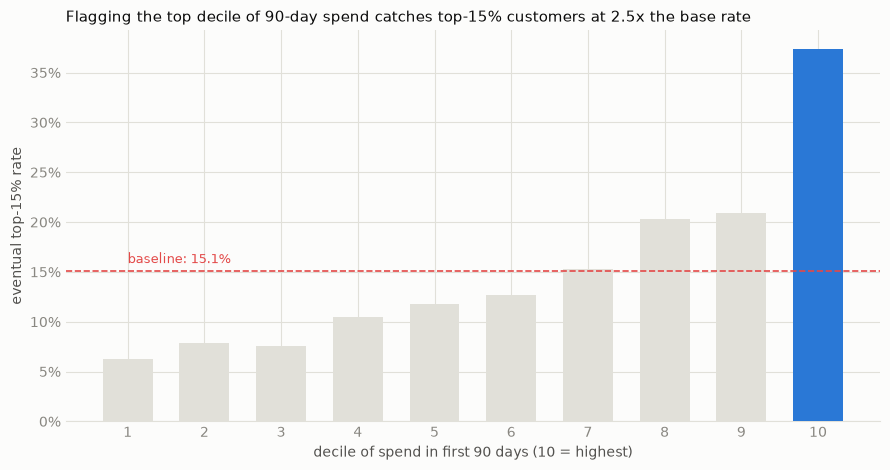

                   rate     n  capture_share
spend_90d_decile                            
1                 0.063  1227          0.042
2                 0.079  1227          0.052
3                 0.076  1227          0.050
4                 0.105  1226          0.070
5                 0.118  1227          0.078
6                 0.127  1227          0.084
7                 0.153  1226          0.102
8                 0.203  1227          0.135
9                 0.209  1227          0.139
10                0.374  1227          0.248
top decile alone captures 24.8% of all eventual top-15% customers


In [14]:
early['spend_90d_decile'] = pd.qcut(early['spend_90d'].rank(method='first'), 10, labels=False) + 1
lift = early.groupby('spend_90d_decile')['is_top15'].agg(rate='mean', n='count')
lift['capture_share'] = early.groupby('spend_90d_decile')['is_top15'].sum() / early['is_top15'].sum()
baseline = early['is_top15'].mean()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(lift.index.astype(str), lift['rate'], color=[BLUE if d == 10 else GRID for d in lift.index], width=0.65, zorder=3)
ax.axhline(baseline, color=NEG, linewidth=1.2, linestyle='--', zorder=4)
ax.text(0, baseline + 0.008, f'baseline: {baseline*100:.1f}%', color=NEG, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_xlabel('decile of spend in first 90 days (10 = highest)')
ax.set_ylabel('eventual top-15% rate')
ax.set_title('Flagging the top decile of 90-day spend catches top-15% customers at 2.5x the base rate', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=False)
plt.tight_layout()
plt.show()

print(lift.round(3))
print(f"top decile alone captures {lift.loc[10, 'capture_share']*100:.1f}% of all eventual top-15% customers")

In [15]:
early['spend_90d_half'] = np.where(early['spend_90d'] >= early['spend_90d'].median(),
                                    'Above-median 90d spend', 'Below-median 90d spend')
combo = early.groupby(['spend_90d_half', 'reordered_within_90d'])['is_top15'].agg(rate='mean', n='count')
combo['lift_vs_baseline'] = combo['rate'] / baseline
print(combo.round(3))

                                              rate     n  lift_vs_baseline
spend_90d_half         reordered_within_90d                               
Above-median 90d spend False                 0.155  2627             1.027
                       True                  0.257  3507             1.706
Below-median 90d spend False                 0.087  5456             0.576
                       True                  0.099   678             0.655


**The two signals compound, but reordering alone doesn't carry much on its own.** Customers who are *both* above-median on 90-day spend *and* reorder within 90 days hit a 25.7% top-15% rate — 1.7x baseline. Drop the spend condition and reordering barely helps (9.9% vs. 8.7% for no-reorder, both *below* baseline) — so the useful rule is "spend meaningfully in the first 90 days," and reordering quickly is a multiplier on top of that, not an independent flag.

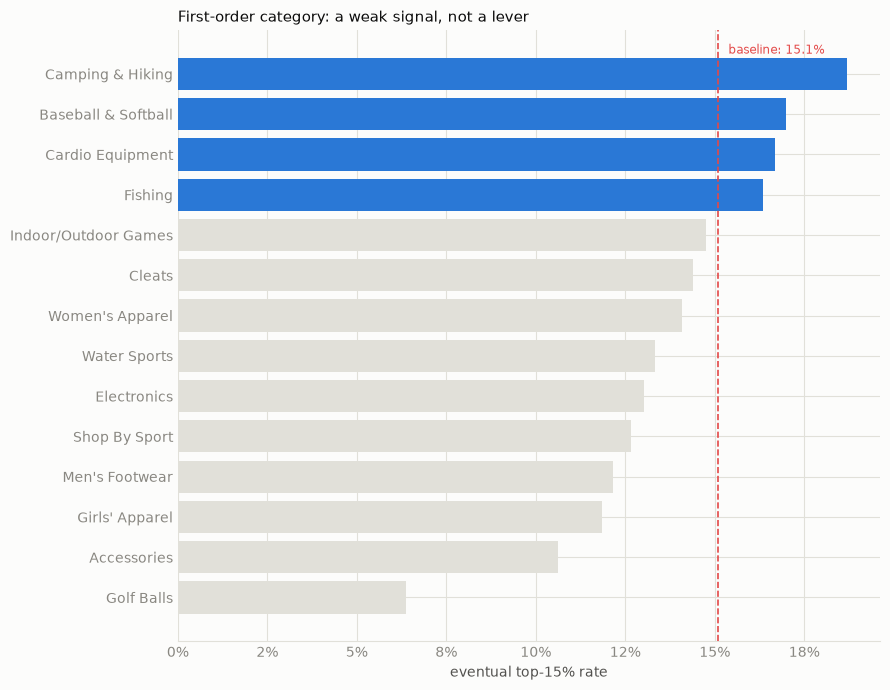

                       rate     n
first_order_category             
Camping & Hiking      0.187  1943
Baseball & Softball   0.170   106
Cardio Equipment      0.167  1517
Fishing               0.163  1224
Indoor/Outdoor Games  0.148  1097
Cleats                0.144  2460
Women's Apparel       0.141   831
Water Sports          0.133   578
Electronics           0.130   269
Shop By Sport         0.127   371
Men's Footwear        0.122  1151
Girls' Apparel        0.118    76
Accessories           0.106   311
Golf Balls            0.064    94


In [16]:
cat = early.groupby('first_order_category')['is_top15'].agg(rate='mean', n='count')
cat = cat[cat['n'] >= 50].sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [BLUE if r >= baseline else GRID for r in cat['rate']]
ax.barh(cat.index[::-1], cat['rate'][::-1], color=colors[::-1], zorder=3)
ax.axvline(baseline, color=NEG, linewidth=1.2, linestyle='--', zorder=4)
ax.text(baseline + 0.003, len(cat) - 0.5, f'baseline: {baseline*100:.1f}%', color=NEG, fontsize=8.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_xlabel('eventual top-15% rate')
ax.set_title('First-order category: a weak signal, not a lever', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=False, y_grid=False)
plt.tight_layout()
plt.show()

print(cat.round(3))

Category of the first order is the weakest of the three candidate signals — a range of only 6.4% (Golf Balls) to 18.7% (Camping & Hiking) around a 15.1% baseline, with several categories sitting right on top of the baseline. There's a mild lean toward outdoor/gear categories over apparel/accessories, but nothing sharp enough to build a targeting rule on, and the smaller categories here are thin samples. Not worth operationalizing on its own.

**Section takeaway:** first-order size is a poor early flag; 90-day spend and a 90-day reorder are decent ones, and best used together. A simple operational rule — "flag any customer whose spend in their first 90 days lands in the top decile, and watch especially closely if they've already placed a 2nd order" — would catch about a quarter of eventual top-15% customers at roughly 2.5x the base rate, using only data available 90 days after acquisition. First-order category isn't worth building into that rule. None of these signals is strong enough to be a precise classifier (this is a lift tool for prioritization, not a high-confidence label) — consistent with the rest of this notebook's finding that top-15% membership is driven by sustained activity level, not a trait visible in a single early transaction.

## Takeaways

- **Top 15% of customers = 28.7% of revenue, 26.2% of profit** — real but modest over-indexing, consistent with `0.8`'s finding that this isn't an 80/20 business.
- **They run a thinner margin (3.31%) than the rest of the base (3.74%).** Highest-revenue ≠ highest-margin — a "best customers" list built on profit would not be the same 1,850 people.
- **They're more active on every activity axis**: ~2x the lifetime orders, longer tenure, and *more* recently active (not a lapsing legacy cohort) — this segment looks healthy and worth retaining, not one to worry about losing.
- **Their share of revenue is remarkably stable month to month** (28.6% ± 1.3pp across all 33 months) — a structural pattern, not a seasonal spike or a one-off cohort.
- **No demographic or operational lever explains membership.** Segment, market, category mix, shipping mode, payment type, discount rate, and delivery reliability are all close to identical between the top 15% and the rest (mild geographic lean toward Central America / Western Europe aside). The only differentiator is activity level — so growing this tier means driving frequency and basket size across the existing base, not targeting a particular segment or region.
- **It's an early-flaggable pattern, not just a retrospective label (§4).** First-order size alone is a weak signal, but spend across the first 90 days (corr +0.26) and placing a 2nd order within 90 days (52.4% of eventual top-15% vs. 30.9% of the rest) both carry real signal, and compound: above-median 90-day spend *and* an early reorder together hit 1.7x the baseline top-15% rate. Flagging the top decile of 90-day spend alone catches ~25% of eventual top-15% customers at 2.5x the base rate — actionable ~90 days after acquisition, not just after the fact. First-order category is too weak to build a rule on.